## 2. Phase 1: Training the Victim Model & Establishing the Baseline
 We trained our target model a ResNet-18 on a strict 50/50 split of the CIFAR-10 dataset (25,000 training members, 25,000 unseen non-members). 

To ensure we had a strong privacy signal r, we made specific design choices to maximize overfitting:
* **No Weight Decay (L2 Regularization):** Set to 0.0 to let the model memorize aggressively.
* **Extended Training:** Pushed to 50 epochs 

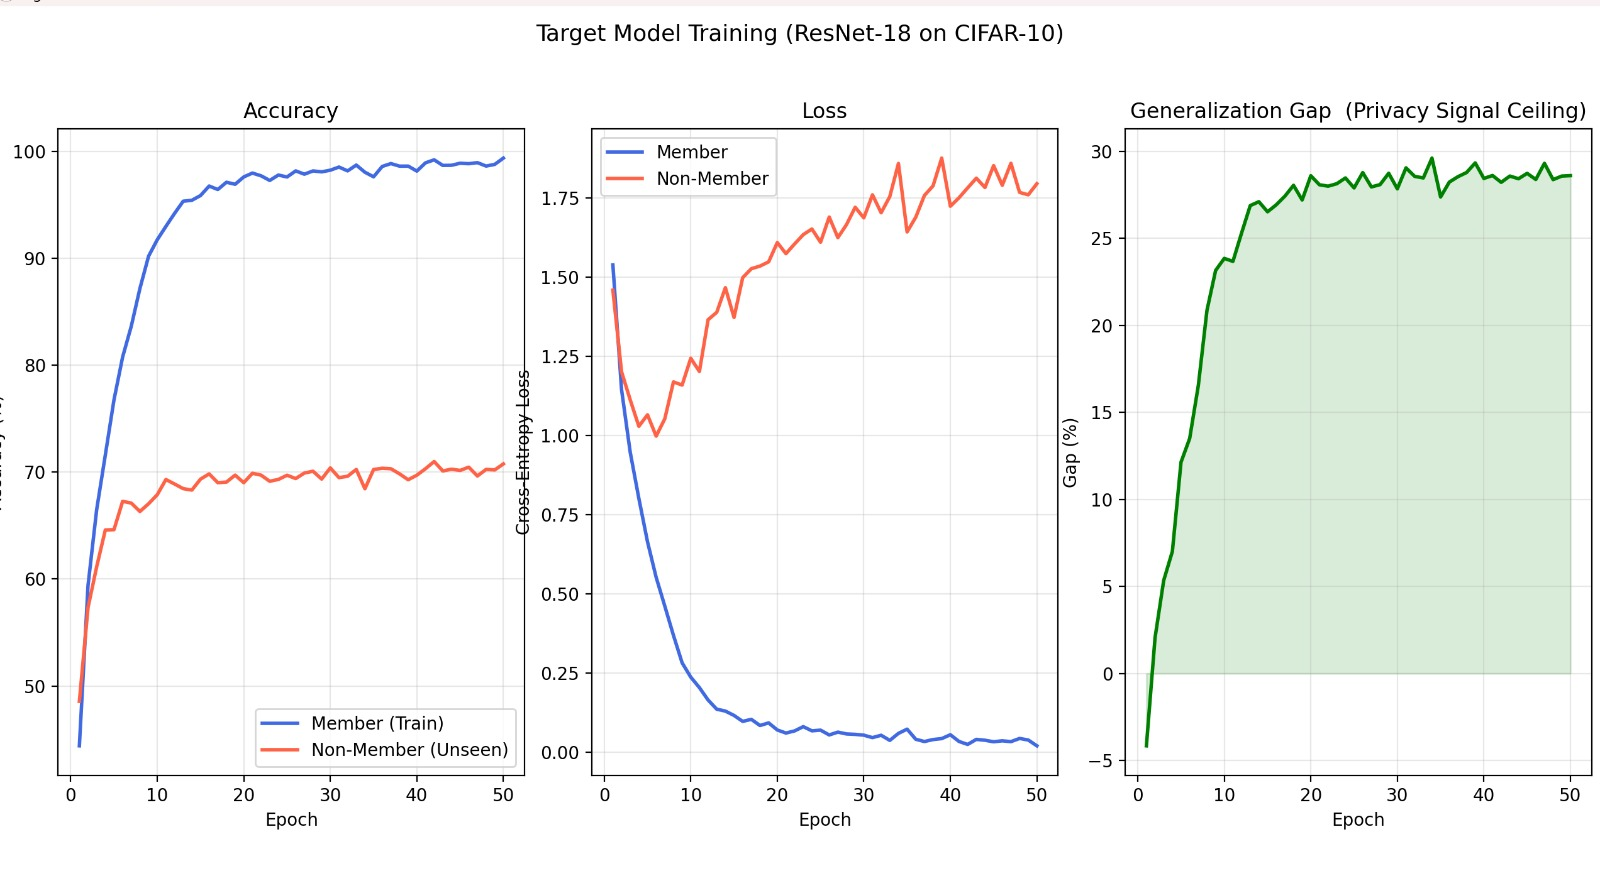

### Target Model Analysis
As seen in the graphs above, our intentional overfitting worked perfectly. The model hit **98.07% Accuracy on Members** but plateaued around **70% on Non-Members**. 

This **~28% Generalization Gap** is crucial. In privacy research, this gap represents the absolute ceiling of theoretical privacy leakage. A naive attacker—who simply guesses "Member" if the model gets the image right, and "Non-Member" if it gets it wrong—would hit an accuracy of roughly 64%. Our objective for the auditor is to significantly beat this 64% naive baseline.

## 3. Phase 2: Feature Engineering (The "Velocity" Concept)
The initial baseline code we started with only extracted 3 features per step. We realized this wasn't giving the neural network enough context, so we completely overhauled the data generation pipeline (`generate_data.py`).

**1. Expanding to 33 Features:**
We expanded our feature extraction to 11 highly specific metrics per step, including standard loss and confidence, but most importantly, we added **Deltas** (the rate of change between steps). Giving the network explicit "velocity" data stops it from having to implicitly guess the math. We also included structural metrics like Layer-4 Cosine Similarity to see how the deep features drifted under attack.

**2. The Multi-Scale Probe (3 $\epsilon$-scales):**
Instead of attacking with one static noise level, we hit every image with three different PGD intensities:
* $\epsilon = 0.01$: A fine probe.
* $\epsilon = 0.04$: The critical "tug-of-war" medium probe.
* $\epsilon = 0.08$: A heavy probe that breaks almost everything.
*(11 features $\times$ 3 scales = 33 dimensions per step)*

**3. Sequence Truncation (Removing Dead Noise):**
We originally tracked 35 PGD steps, but realized steps 13-35 were effectively "dead data." By step 15, both members and non-members were so heavily corrupted that their trajectories flatlined at 0% confidence. We truncated the sequence to just the **first 12 steps** to force the auditor to look exclusively at the active "tug-of-war" phase.

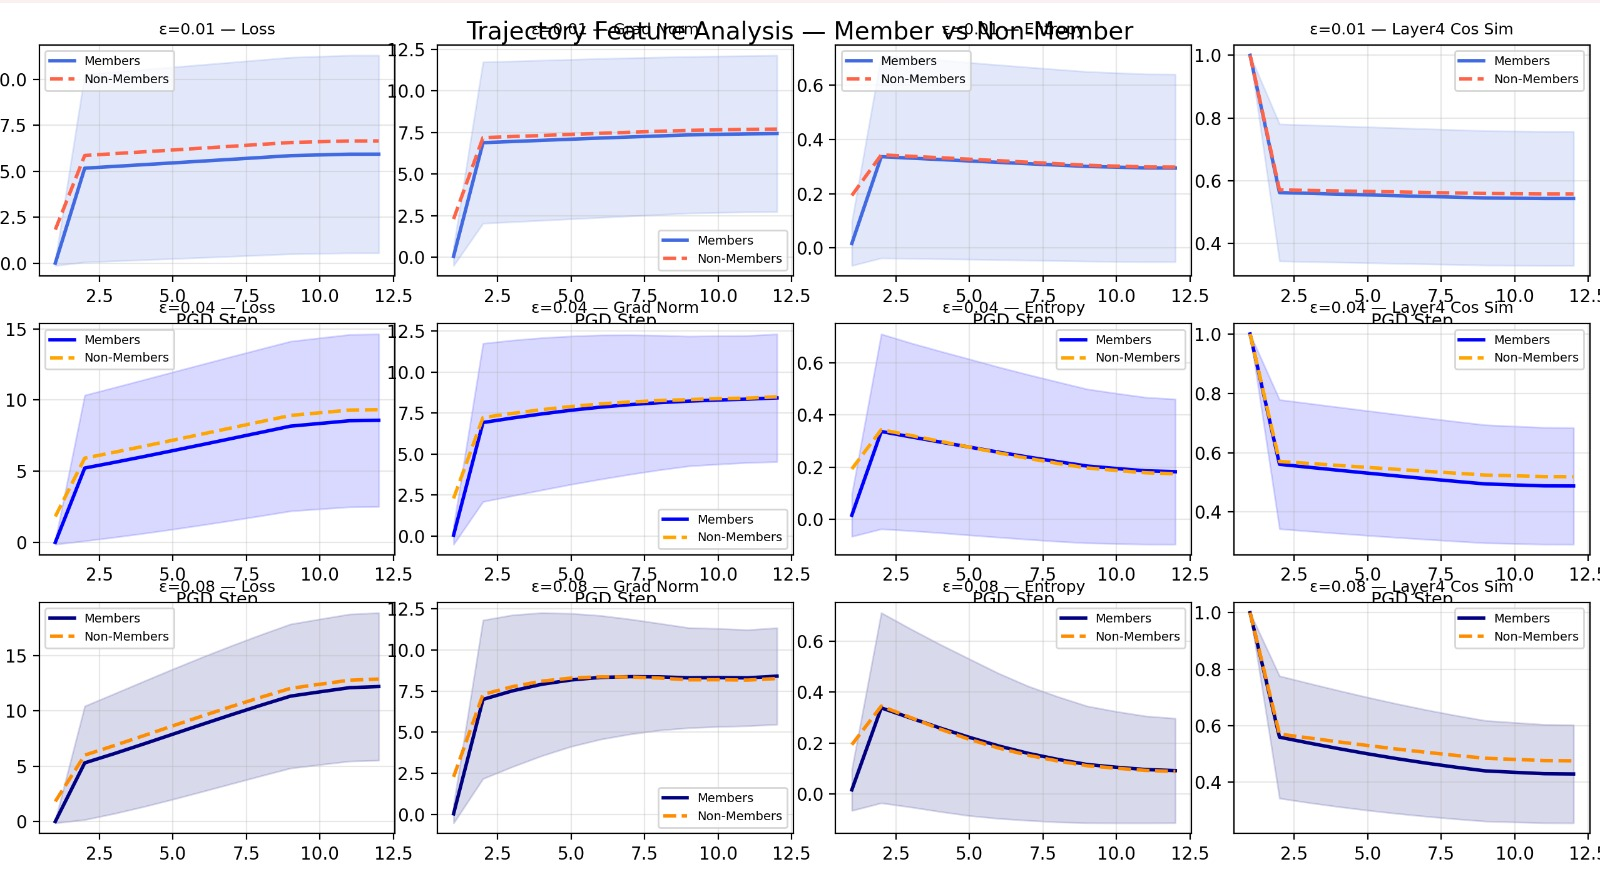

As shown in our multi-scale analysis above, the true gap between Members (blue) and Non-Members (orange) exists heavily in the medium and fine probes.

## 4. Phase 3: Upgrading to the Trajectory Transformer
 

We replaced the LSTM with a **Trajectory Transformer** (`auditor_arch.py`). 
* **Self-Attention:** Unlike the LSTM, the Transformer's attention heads can look at all 12 steps simultaneously. It learns exactly *which* step in the trajectory contains the critical breaking point and applies heavy mathematical weight to it.
* **Learnable Positional Embeddings:** Rather than standard sinusoidal embeddings, we let the network natively learn the importance of specific PGD step indices.
* **Regularization:** Because Transformers are prone to overfitting on small sequences, we added Label Smoothing to our BCE Loss (preventing overconfidence), Gradient Clipping, and a Cosine Annealing Learning Rate scheduler.

## 5. Phase 4: Training the Auditor
We trained the Trajectory Transformer for 80 epochs.

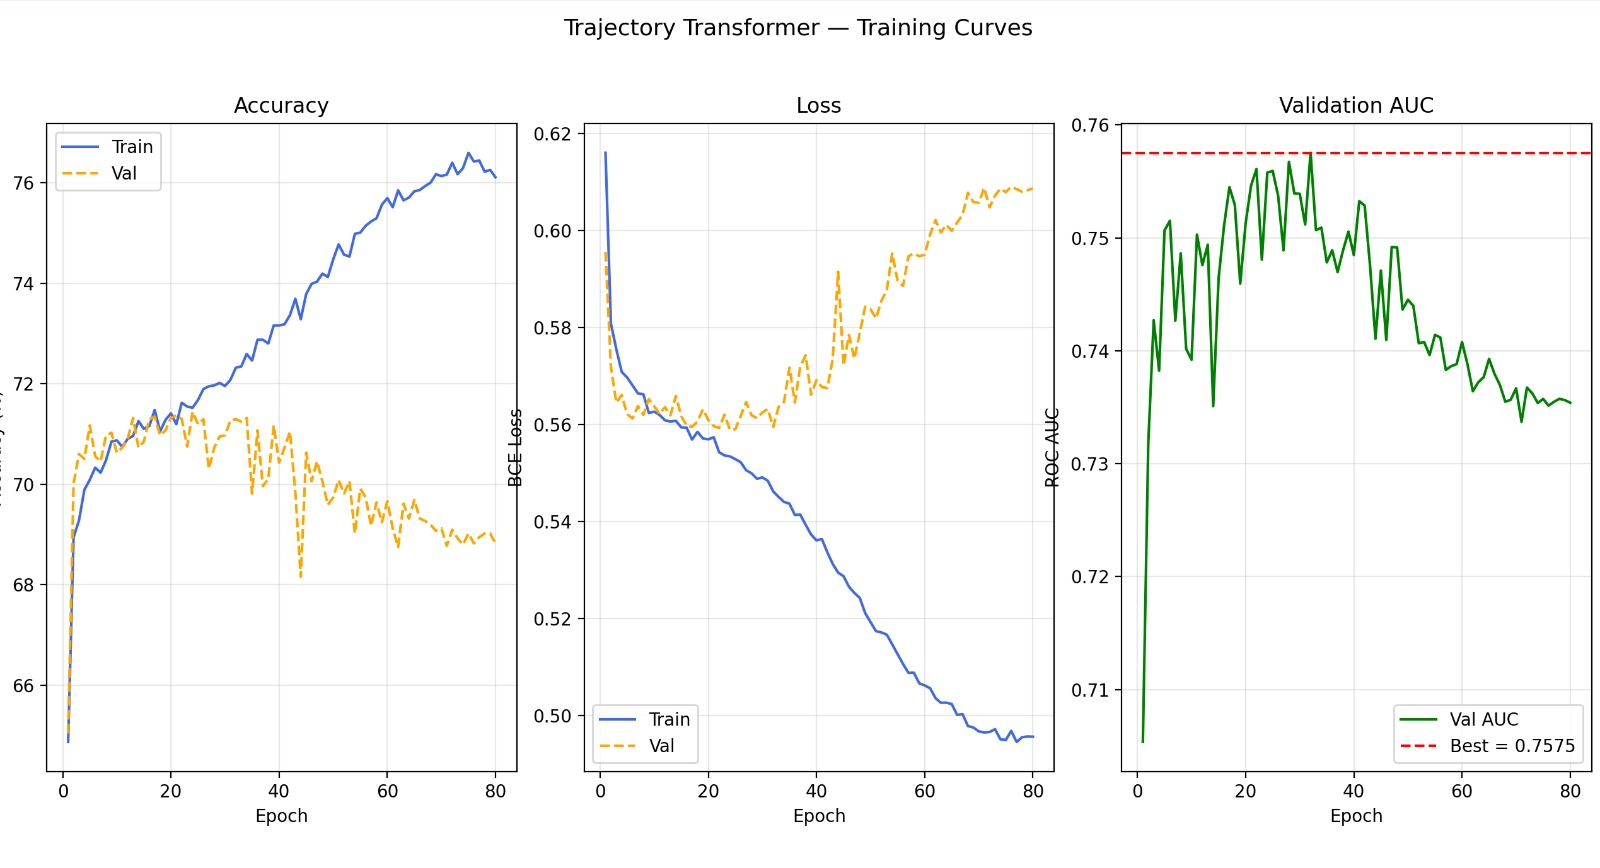

The training curves show a very healthy optimization process. The Cosine Annealing LR allows the validation AUC (green line) to peak smoothly at **0.7575** around epoch 35-40 before the model begins to overfit. We utilize early-stopping to grab this exact best-checkpoint for our final evaluation.

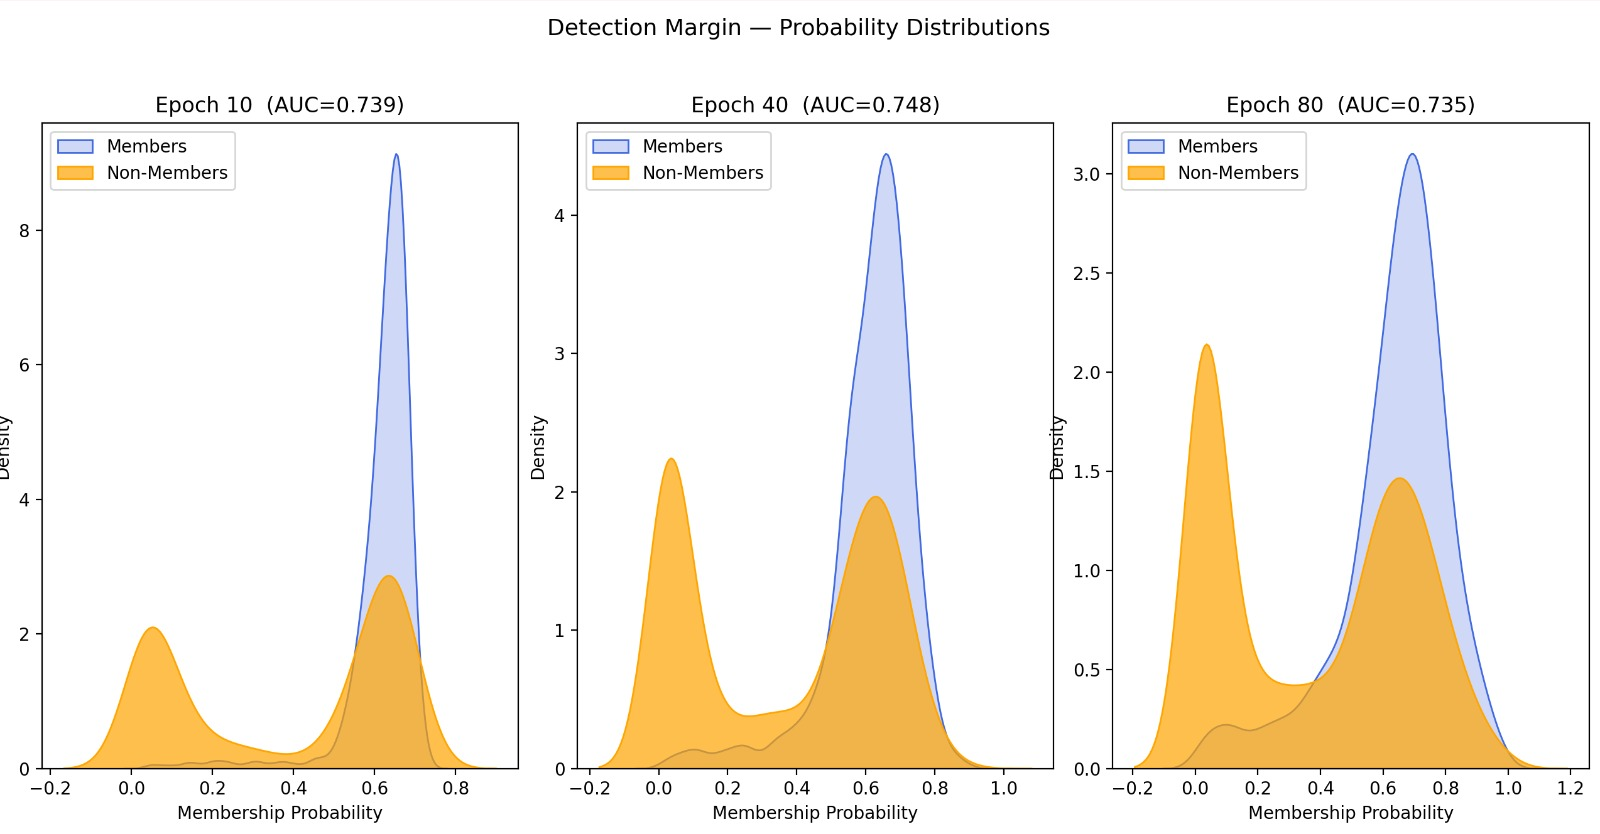

If we look at the evolution of the probability distributions, we can visually see the Transformer learning to separate the classes. By Epoch 40, it has successfully isolated a large chunk of Non-Members (orange) toward the left side of the threshold, proving that the multi-scale trajectory data contains highly viable privacy signals.

## 6. Phase 5: Final Evaluation & Results Analysis
We evaluated the best-checkpoint Transformer on the held-out validation set. 

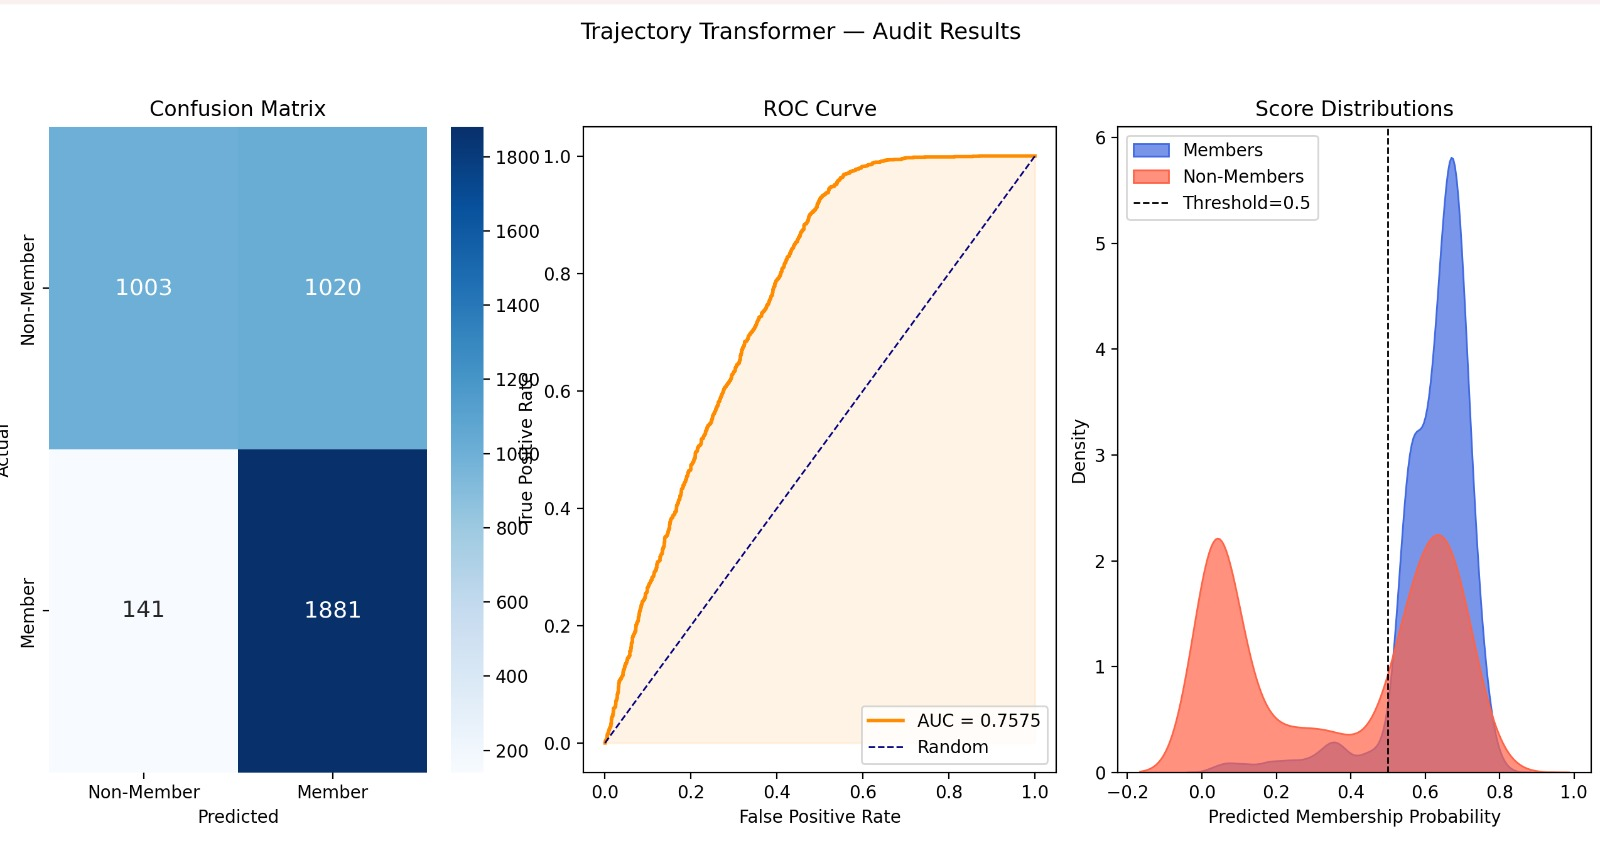

### Results Breakdown
* **Accuracy: 71.30%**
* **Recall: 93.03%**
* **Precision: 64.84%**
* **ROC AUC: 0.7575**

We successfully broke the 70% accuracy barrier, significantly outperforming the naive 64% baseline. The ROC AUC of 0.7575 is highly competitive for a shadow-model-free MIA.